In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [8]:
# try to get the original splits
### write a script to do this!!!!
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_rnaseq.csv', header = 0, index_col = 0)

prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)
prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)

#filter clin and counts by prot
# clin = clin.filter(items = prot.index, axis = 0)

In [9]:
# import data with previous splits

# seed 7
prot_7_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_1_tr.csv', header=None)
prot_7_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_1_te.csv', header=None)
prot_7_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_1_featname.csv', index_col=0, header=None)

counts_7_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_2_tr.csv', header=None)
counts_7_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_2_te.csv', header=None)
counts_7_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_2_featname.csv', index_col=0, header=None)

clin_7_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_3_tr.csv', header=None)
clin_7_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_3_te.csv', header=None)
clin_7_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7_3_featname.csv', index_col=0, header=None)

labels_7_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7labels_tr.csv', header=None)
labels_7_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/7labels_te.csv', header=None)

# seed 47
prot_47_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_1_tr.csv', header=None)
prot_47_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_1_te.csv', header=None)
prot_47_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_1_featname.csv', index_col=0, header=None)

counts_47_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_2_tr.csv', header=None)
counts_47_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_2_te.csv', header=None)
counts_47_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_2_featname.csv', index_col=0, header=None)

clin_47_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_3_tr.csv', header=None)
clin_47_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_3_te.csv', header=None)
clin_47_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47_3_featname.csv', index_col=0, header=None)

labels_47_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47labels_tr.csv', header=None)
labels_47_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/47labels_te.csv', header=None)

# seed 99
prot_99_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_1_tr.csv', header=None)
prot_99_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_1_te.csv', header=None)
prot_99_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_1_featname.csv', index_col=0, header=None)

counts_99_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_2_tr.csv', header=None)
counts_99_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_2_te.csv', header=None)
counts_99_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_2_featname.csv', index_col=0, header=None)

clin_99_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_3_tr.csv', header=None)
clin_99_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_3_te.csv', header=None)
clin_99_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_3_featname.csv', index_col=0, header=None)

labels_99_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99labels_tr.csv', header=None)
labels_99_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99labels_te.csv', header=None)

# seed 88
prot_88_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_1_tr.csv', header=None)
prot_88_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_1_te.csv', header=None)
prot_88_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/99_1_featname.csv', index_col=0, header=None)

counts_88_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_2_tr.csv', header=None)
counts_88_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_2_te.csv', header=None)
counts_88_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_2_featname.csv', index_col=0, header=None)

clin_88_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_3_tr.csv', header=None)
clin_88_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_3_te.csv', header=None)
clin_88_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88_3_featname.csv', index_col=0, header=None)

labels_88_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88labels_tr.csv', header=None)
labels_88_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/88labels_te.csv', header=None)

# seed 238
prot_238_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_1_tr.csv', header=None)
prot_238_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_1_te.csv', header=None)
prot_238_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_1_featname.csv', index_col=0, header=None)

counts_238_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_2_tr.csv', header=None)
counts_238_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_2_te.csv', header=None)
counts_238_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_2_featname.csv', index_col=0, header=None)

clin_238_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_3_tr.csv', header=None)
clin_238_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_3_te.csv', header=None)
clin_238_features = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238_3_featname.csv', index_col=0, header=None)

labels_238_tr = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238labels_tr.csv', header=None)
labels_238_te = pd.read_csv('/Users/smasarone/Documents/omics_integration(PhD)/238labels_te.csv', header=None)

In [10]:
# merge train and test

def merge_data(prot_tr, count_tr, clin_tr, prot_te, count_te, clin_te, feat_p, feat_c, feat_clin):
    prot_tr.columns = feat_p.index
    count_tr.columns = feat_c.index
    clin_tr.columns = feat_clin.index
    train = prot_tr.join(count_tr).join(clin_tr)
    
    prot_te.columns = feat_p.index
    count_te.columns = feat_c.index
    clin_te.columns = feat_clin.index
    test = prot_te.join(count_te).join(clin_te)

    return train, test

train238, test238 = merge_data(prot_238_tr, counts_238_tr, clin_238_tr, prot_238_te, counts_238_te, clin_238_te, 
           prot_238_features , counts_238_features,clin_238_features) 

train88, test88 = merge_data(prot_88_tr, counts_88_tr, clin_88_tr, prot_88_te, counts_88_te, clin_88_te, 
           prot_88_features ,counts_88_features,clin_88_features) 

train99, test99 = merge_data(prot_99_tr, counts_99_tr, clin_99_tr, prot_99_te, counts_99_te, clin_99_te, 
           prot_99_features ,counts_99_features,clin_99_features) 

train47, test47 = merge_data(prot_47_tr, counts_47_tr, clin_47_tr, prot_47_te, counts_47_te, clin_47_te, 
           prot_47_features ,counts_47_features,clin_47_features) 

train7, test7 = merge_data(prot_7_tr, counts_7_tr, clin_7_tr, prot_7_te, counts_7_te, clin_7_te, 
           prot_7_features ,counts_7_features,clin_7_features) 


datasets = [(train238, test238), (train88, test88), (train99, test99), (train47, test47), (train7, test7)]

In [11]:
labels = [(labels_238_tr, labels_238_te), (labels_88_tr, labels_88_te),
          (labels_99_tr, labels_99_te), (labels_47_tr, labels_47_te), (labels_7_tr, labels_7_te)]

In [12]:
labels[0][0]

,0
0,1
1,1
2,0
3,0
4,1
...,...
304,0
305,0
306,1
307,0


In [13]:
# need to cross validate for each of them

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import model_selection
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, recall_score
    

models = [
          ('LogReg', LogisticRegression(class_weight = 'balanced')), 
          ('RF', RandomForestClassifier(max_depth=2, class_weight = 'balanced')),
          ('KNN', KNeighborsClassifier()),
          ('SVM', SVC(class_weight = 'balanced', C = 0.1)), 
]
results = []
f1_weig=[]
recall=[]
names = []

for model in models:
    for idx, fold in enumerate(datasets): 
        X_train = fold[0]
        X_test = fold[1]
        y_train = labels[idx][0].iloc[:,0]
        y_test = labels[idx][1].iloc[:,0]
        
        clf = model[1].fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        roc_auc = roc_auc_score(y_test, y_pred)
        f1_scores = f1_score(y_test, y_pred, average='binary')
        recall_ = recall_score(y_test, y_pred,)
        results.append(roc_auc)
        f1_weig.append(f1_scores)
        recall.append(recall_)
        names.append(model[0])
        
final = pd.DataFrame(results, columns=['test_roc_auc'])
final['model'] = names
final['test_f1'] = f1_weig
final['recall'] = recall

/usr/local/anaconda3/envs/omics_integration/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/anaconda3/envs/omics_integration/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

In [14]:
final

,test_roc_auc,model,test_f1,recall
0,0.755023,LogReg,0.655172,0.633333
1,0.822554,LogReg,0.692308,0.782609
2,0.800699,LogReg,0.705882,0.692308
3,0.790476,LogReg,0.689655,0.714286
4,0.835039,LogReg,0.733333,0.814815
5,0.760959,RF,0.656250,0.700000
6,0.828533,RF,0.666667,0.869565
7,0.774476,RF,0.644068,0.730769
8,0.835238,RF,0.727273,0.857143
9,0.790205,RF,0.666667,0.777778


In [28]:
final[final['model']=='SVM']['test_f1'].mean()


0.6350292938637064

In [31]:
np.mean([0.57777778, 0.45714286, 0.54166667, 0.375     , 0.48648649])

0.4876147599999999

In [187]:
# auc
# this has mogonet (all), VAE+ RF and VAE+LR
aucs_mogonet = [0.836, 0.778, 0.796, 0.876, 0.745,                             
                0.75294118, 0.62178703, 0.73333333, 0.59180036, 0.85833333,    
                0.81437908, 0.56793146, 0.71372549, 0.62566845, 0.725]
df_mogo = pd.DataFrame(aucs_mogonet, columns =['test_roc_auc'])
df_mogo['model'] = ['MOGONET']*5+['VAE+RF']*5 +['VAE+LR']*5
final_ = final.append(df_mogo) 

/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_48748/38632450.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_ = final.append(df_mogo)


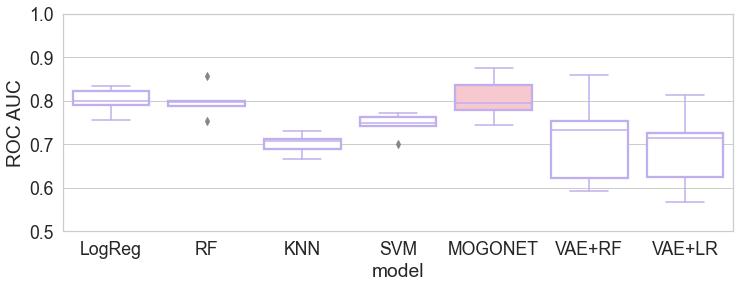

In [218]:
palette2 = sns.color_palette(["#A8BFC6", "#c6d5da", "#f6f8f9"])
palette_chapter = sns.color_palette(["#c0afec", "#edacac", "#bcf9a7"])

# set edgecolour for boxplot
PROPS = {
    'boxprops':{'edgecolor':'#c0afec'},
    'medianprops':{'color':'#c0afec'},
    'whiskerprops':{'color':'#c0afec'},
    'capprops':{'color':'#c0afec'}
}

sns.set_style("whitegrid")
plt.figure(figsize = (12, 4))
plt.ylim(0.5, 1.0)
sns.set(font_scale=1.6)
highlight = sns.color_palette(['white', 'white', 'white','white','pink', 'white','white',])
ax = sns.boxplot(x='model', y='test_roc_auc', data = final_, palette= highlight, **PROPS)
plt.setp(ax.patches, linewidth=2.3)
plt.ylabel("ROC AUC")
image_name = '/Users/smasarone/Downloads/ROC_AUC.pdf'
plt.savefig(image_name, dpi=1200, bbox_inches='tight') 

### F1 binary 

/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_48748/4081054633.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final2 = selected2.append(df_mogo)


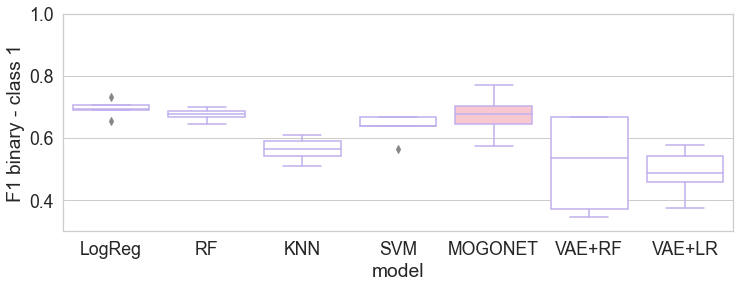

In [215]:
# "f1 binary" (only looks at class1)
selected2 = final.loc[:,'model':'test_f1']
f1_mogonet =[0.772,      0.644,      0.679,      0.704,      0.576,
             0.53658537, 0.34482759, 0.66666667, 0.37037037, 0.66666667,
             0.57777778, 0.45714286, 0.54166667, 0.375     , 0.48648649]

df_mogo = pd.DataFrame(f1_mogonet, columns =['test_f1'])
df_mogo['model'] = ['MOGONET']*5+['VAE+RF']*5 +['VAE+LR']*5
final2 = selected2.append(df_mogo)

sns.set_style("whitegrid")
plt.figure(figsize = (12, 4))
plt.ylim(0.3, 1.0)
sns.set(font_scale=1.6)
sns.boxplot(x='model', y='test_f1', data = final2, **PROPS, palette= highlight)
plt.ylabel("F1 binary - class 1")
image_name = '/Users/smasarone/Downloads/F1.pdf'
plt.savefig(image_name, dpi=1200, bbox_inches='tight') 

/var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/ipykernel_48748/3674585631.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final3 = selected3.append(df_mogo)


Text(0, 0.5, 'Recall binary - class 1')

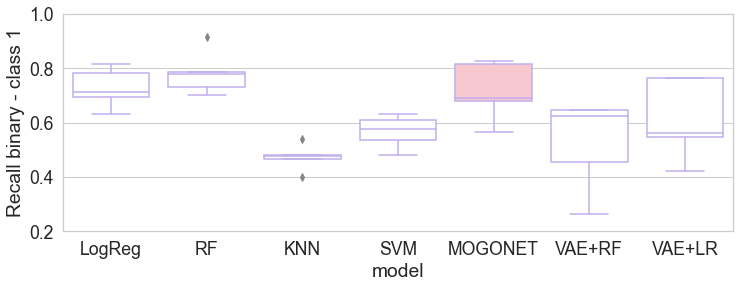

In [216]:
### Recall
selected3 = final.loc[:,'model':'recall']
recall_mogonet =[0.815,   0.68,   0.692, 0.826,    0.567,
                0.64705882, 0.26315789, 0.64705882, 0.45454545, 0.625 ,
                0.76470588, 0.42105263, 0.76470588, 0.54545455, 0.5625]

df_mogo = pd.DataFrame(recall_mogonet, columns =['recall'])
df_mogo['model'] = ['MOGONET']*5+['VAE+RF']*5 +['VAE+LR']*5
final3 = selected3.append(df_mogo)

sns.set_style("whitegrid")
plt.figure(figsize = (12, 4))
plt.ylim(0.2, 1.0)
sns.set(font_scale=1.8)
sns.boxplot(x='model', y='recall', data = final3, **PROPS, palette = highlight)
plt.ylabel("Recall binary - class 1")